# Ejercicio 8 — Incorporación de 2025 y análisis completo

`DEFAULT_YEARS` pasó a `(2024, 2025, 2026)`. Este notebook verifica la incorporación, comprueba que todas las
consultas anteriores siguen funcionando y analiza la evolución de los indicadores en los tres años.
Consultas nuevas en `sql/08_three_years/`; documentación en `docs/08_three_years.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import matplotlib.pyplot as plt
import pandas as pd

import charts
import taxi_db

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
charts.apply_style()
con = taxi_db.connect()

import subprocess
import time

## 8.1 y 8.2 Descarga

Segunda ejecución del script: los 64 archivos ya existen y no se descarga ninguno.

In [2]:
result = subprocess.run([sys.executable, "scripts/download_data.py"], cwd=taxi_db.PROJECT_ROOT, capture_output=True, text=True)
print("\n".join(result.stdout.splitlines()[-12:]))

Zonas: data/raw/zones/taxi_zone_lookup.csv ya existe, se omite

RESUMEN
  años          : 2024, 2025, 2026
  descargados   : 0
  ya existían   : 64
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0


In [3]:
inventory = taxi_db.show(con, "05_incremental/01_inventory_by_year.sql")
inventory

SELECT
    split_part(file_name, '/', 3) AS taxi_type,
    CAST(split_part(file_name, '/', 4) AS INTEGER) AS year,
    count(*) AS files,
    sum(num_rows) AS rows_in_metadata
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY ALL
ORDER BY taxi_type DESC, year;


,taxi_type,year,files,rows_in_metadata
0,yellow,2024,12,41169720.0
1,yellow,2025,12,48722602.0
2,yellow,2026,8,29703355.0
3,green,2024,12,660218.0
4,green,2025,12,591375.0
5,green,2026,8,337114.0


In [4]:
missing = taxi_db.show(con, "05_incremental/02_missing_months.sql")
missing

WITH present AS (
    SELECT
        split_part(file, '/', 3) AS taxi_type,
        CAST(split_part(file, '/', 4) AS INTEGER) AS year,
        CAST(regexp_extract(file, '-(\d{2})\.parquet$', 1) AS INTEGER) AS month
    FROM glob('data/raw/*/*/*.parquet')
),
expected AS (
    SELECT t.taxi_type, y.year, m.month
    FROM (SELECT DISTINCT taxi_type FROM present) AS t
    CROSS JOIN (SELECT DISTINCT year FROM present) AS y
    CROSS JOIN range(1, 13) AS m(month)
)
SELECT
    e.taxi_type,
    e.year,
    count(p.month) AS months_present,
    list(e.month ORDER BY e.month) FILTER (WHERE p.month IS NULL) AS missing_months
FROM expected AS e
LEFT JOIN present AS p USING (taxi_type, year, month)
GROUP BY e.taxi_type, e.year
ORDER BY e.taxi_type DESC, e.year;


,taxi_type,year,months_present,missing_months
0,yellow,2024,12,<NA>
1,yellow,2025,12,<NA>
2,yellow,2026,8,"[9, 10, 11, 12]"
3,green,2024,12,<NA>
4,green,2025,12,<NA>
5,green,2026,8,"[9, 10, 11, 12]"


In [5]:
schema = taxi_db.show(con, "05_incremental/03_schema_by_year.sql")
schema

PIVOT (
    SELECT
        name AS column_name,
        split_part(file_name, '/', 3) || '_' || split_part(file_name, '/', 4) AS taxi_year
    FROM parquet_schema('data/raw/*/*/*.parquet')
    WHERE type IS NOT NULL
)
ON taxi_year
USING count(*)
ORDER BY column_name;


,column_name,green_2024,green_2025,green_2026,yellow_2024,yellow_2025,yellow_2026
0,Airport_fee,0,0,0,12,12,8
1,DOLocationID,12,12,8,12,12,8
2,PULocationID,12,12,8,12,12,8
3,RatecodeID,12,12,8,12,12,8
4,VendorID,12,12,8,12,12,8
5,cbd_congestion_fee,0,12,8,0,12,8
6,congestion_surcharge,12,12,8,12,12,8
7,ehail_fee,12,12,8,0,0,0
8,extra,12,12,8,12,12,8
9,fare_amount,12,12,8,12,12,8


In [6]:
rows_by_year = taxi_db.show(con, "05_incremental/04_rows_by_year.sql")
rows_by_year

SELECT
    r.taxi_type,
    r.source_year AS year,
    r.trips AS raw_trips,
    c.trips AS clean_trips,
    round(100.0 * (r.trips - c.trips) / r.trips, 2) AS pct_discarded,
    r.first_pickup,
    r.last_pickup
FROM (
    SELECT taxi_type, source_year, count(*) AS trips, min(pickup_datetime) AS first_pickup, max(pickup_datetime) AS last_pickup
    FROM trips
    GROUP BY ALL
) AS r
JOIN (
    SELECT taxi_type, source_year, count(*) AS trips
    FROM trips_clean
    GROUP BY ALL
) AS c USING (taxi_type, source_year)
ORDER BY r.taxi_type DESC, year;


,taxi_type,year,raw_trips,clean_trips,pct_discarded,first_pickup,last_pickup
0,yellow,2024,41169720,39688329,3.60,2002-12-31 16:46:07,2026-06-26 23:53:12
1,yellow,2025,48722602,44690117,8.28,2007-12-05 18:45:00,2025-12-31 23:59:59
2,yellow,2026,29703355,28593831,3.74,2001-01-01 09:23:58,2026-08-31 23:59:59
3,green,2024,660218,621093,5.93,2008-12-31 00:00:00,2025-01-01 22:21:15
4,green,2025,591375,560856,5.16,2008-12-31 15:13:04,2026-01-01 21:09:39
5,green,2026,337114,322606,4.30,2008-12-31 17:35:31,2026-08-31 23:58:28


## 8.3 Las consultas anteriores sobre los tres años

Se ejecutan sin cambios las 37 consultas de los Ejercicios 3, 4 y 5.

In [7]:
results = []
for path in sorted(taxi_db.SQL_DIR.glob("0[345]_*/*.sql")):
    name = str(path.relative_to(taxi_db.SQL_DIR))
    start = time.perf_counter()
    try:
        rows = len(taxi_db.query(con, name))
        status = "ok"
    except Exception as error:
        rows, status = 0, f"error: {error}"
    results.append({"query": name, "status": status, "rows": rows, "seconds": round(time.perf_counter() - start, 2)})
results = pd.DataFrame(results)
print(results.status.value_counts())
results

status
ok    37
Name: count, dtype: int64


,query,status,rows,seconds
0,03_exploration/01_file_inventory.sql,ok,6,0.00
1,03_exploration/02_rows_per_file.sql,ok,64,0.01
2,03_exploration/03_total_rows.sql,ok,3,0.68
3,03_exploration/04_columns_by_file.sql,ok,25,0.01
4,03_exploration/05_column_types_yellow.sql,ok,21,0.00
5,03_exploration/06_column_types_green.sql,ok,22,0.00
6,03_exploration/07_type_conflicts.sql,ok,0,0.01
7,03_exploration/08_sample_yellow.sql,ok,5,0.10
8,03_exploration/09_sample_green.sql,ok,5,0.01
9,03_exploration/10_summary_yellow.sql,ok,21,22.15


## 8.4 Tablero actualizado

La base materializada se reconstruyó con los tres años (`scripts/build_database.py`, con Metabase detenido) y
`scripts/metabase_dashboard.py` volvió a ejecutar las mismas 14 tarjetas, sin cambiar ninguna consulta.

![Tablero con 2024, 2025 y 2026](../docs/07_dashboard/dashboard_2024_2025_2026.png)

Los indicadores también se pueden leer desde la base materializada:

In [8]:
table_con = taxi_db.connect(taxi_db.DATABASE_PATH, read_only=True, views=False)
taxi_db.show(table_con, "07_indicators/01_kpi_summary.sql")

SELECT
    count(*) AS trips,
    round(sum(total_amount) / 1e6, 1) AS revenue_musd,
    round(avg(total_amount), 2) AS avg_ticket,
    count(DISTINCT source_year) AS years,
    min(make_date(source_year, source_month, 1)) AS first_month,
    max(make_date(source_year, source_month, 1)) AS last_month
FROM trips_clean;


,trips,revenue_musd,avg_ticket,years,first_month,last_month
0,114476832,3324.5,29.04,3,2024-01-01,2026-08-01


In [9]:
taxi_db.show(table_con, "07_indicators/06_payment_mix.sql")

SELECT
    CAST(source_year AS VARCHAR) AS year,
    CASE payment_type
        WHEN 1 THEN 'Tarjeta'
        WHEN 2 THEN 'Efectivo'
        WHEN 0 THEN 'Flex fare'
        ELSE 'Otro o nulo'
    END AS payment,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY source_year), 2) AS pct_of_trips
FROM trips_clean
GROUP BY source_year, payment
ORDER BY year, pct_of_trips DESC;


,year,payment,pct_of_trips
0,2024,Tarjeta,75.91
1,2024,Efectivo,13.51
2,2024,Flex fare,9.17
3,2024,Otro o nulo,1.41
4,2025,Tarjeta,68.88
5,2025,Flex fare,19.55
6,2025,Efectivo,9.92
7,2025,Otro o nulo,1.65
8,2026,Tarjeta,65.64
9,2026,Flex fare,24.36


In [10]:
taxi_db.show(table_con, "07_indicators/08_airport_share.sql")

WITH classified AS (
    SELECT
        t.source_year,
        t.total_amount,
        'Airports' IN (pu.service_zone, do_.service_zone)
            OR 'EWR' IN (pu.service_zone, do_.service_zone) AS is_airport
    FROM trips_clean AS t
    LEFT JOIN zones AS pu ON pu.location_id = t.PULocationID
    LEFT JOIN zones AS do_ ON do_.location_id = t.DOLocationID
)
SELECT
    CAST(source_year AS VARCHAR) AS year,
    round(100.0 * count(*) FILTER (WHERE is_airport) / count(*), 2) AS pct_trips,
    round(100.0 * sum(total_amount) FILTER (WHERE is_airport) / sum(total_amount), 2) AS pct_revenue
FROM classified
GROUP BY source_year
ORDER BY year;


,year,pct_trips,pct_revenue
0,2024,10.02,27.57
1,2025,8.78,23.95
2,2026,8.10,20.90


## 8.5 Evolución de los indicadores

### Resumen anual con los mismos meses (enero a agosto)

In [11]:
summary = taxi_db.show(con, "08_three_years/01_yearly_summary.sql")
summary

WITH common_months AS (
    SELECT CAST(regexp_extract(file, '-(\d{2})\.parquet$', 1) AS INTEGER) AS month
    FROM glob('data/raw/yellow/*/*.parquet')
    GROUP BY month
    HAVING count(*) = (SELECT count(DISTINCT split_part(file, '/', 4)) FROM glob('data/raw/yellow/*/*.parquet'))
),
airport_zones AS (
    SELECT location_id
    FROM zones
    WHERE service_zone IN ('Airports', 'EWR')
)
SELECT
    source_year AS year,
    min(source_month) || '-' || max(source_month) AS months,
    count(*) AS trips,
    round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)), 0) AS trips_per_day,
    round(sum(total_amount) / 1e6, 1) AS revenue_musd,
    round(avg(total_amount), 2) AS avg_ticket,
    round(avg(fare_amount), 2) AS avg_fare,
    round(quantile_cont(trip_distance, 0.5), 2) AS median_miles,
    round(approx_quantile(duration_minutes, 0.5), 1) AS median_minutes,
    round(approx_quantile(trip_distance / (duration_minutes / 60), 0.5), 1) AS median_mph,
    round(100.0 * count(*) FI

,year,months,trips,trips_per_day,revenue_musd,avg_ticket,avg_fare,median_miles,median_minutes,median_mph,pct_green,pct_flex_fare,pct_card,pct_cash,pct_airport,pct_cbd_fee
0,2024,1-8,25916674,106216.0,732.2,28.25,19.50,1.80,12.7,9.5,1.61,8.9,75.8,14.0,10.1,0.0
1,2025,1-8,29353465,120796.0,829.6,28.26,19.52,1.87,13.0,9.7,1.28,19.2,68.9,10.2,8.8,72.2
2,2026,1-8,28916437,118998.0,871.6,30.14,21.19,1.92,14.1,9.3,1.12,24.4,65.6,9.2,8.1,71.7


### Viajes por día, mes a mes, por año

In [12]:
trend = taxi_db.show(con, "05_incremental/06_monthly_trend.sql")
trend

SELECT
    taxi_type,
    source_year AS year,
    source_month AS month,
    count(*) AS trips,
    round(count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)), 0) AS trips_per_day,
    round(avg(total_amount), 2) AS avg_total
FROM trips_clean
GROUP BY ALL
ORDER BY taxi_type DESC, year, month;


,taxi_type,year,month,trips,trips_per_day,avg_total
0,yellow,2024,1,2868050,92518.0,27.34
1,yellow,2024,2,2899878,99996.0,27.23
2,yellow,2024,3,3438402,110916.0,27.85
3,yellow,2024,4,3412596,113753.0,28.18
4,yellow,2024,5,3616087,116648.0,28.99
5,yellow,2024,6,3426573,114219.0,28.68
6,yellow,2024,7,2972316,95881.0,28.97
7,yellow,2024,8,2865750,92444.0,29.21
8,yellow,2024,9,3482540,116085.0,29.48
9,yellow,2024,10,3680364,118721.0,29.38


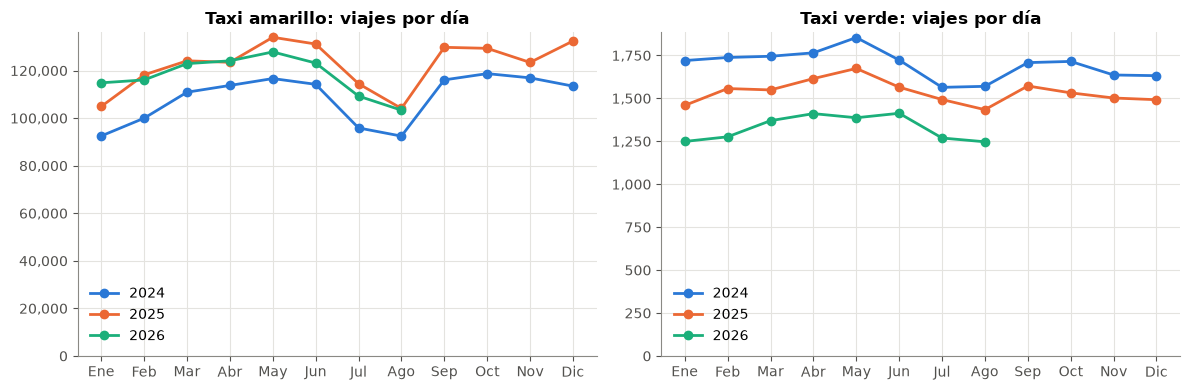

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, taxi in zip(axes, ["yellow", "green"]):
    for year, data in trend[trend.taxi_type == taxi].groupby("year"):
        ax.plot(data.month, data.trips_per_day, marker="o", color=charts.YEAR_COLORS[year], label=str(year))
    ax.set_title(f"Taxi {charts.TAXI_LABELS[taxi].lower()}: viajes por día")
    ax.set_xticks(range(1, 13), charts.MONTHS)
    ax.set_ylim(0, None)
    charts.thousands(ax)
    ax.legend()
plt.tight_layout()
plt.show()

### Cambio interanual por mes

In [14]:
yoy = taxi_db.show(con, "08_three_years/02_year_over_year.sql")
yoy

WITH monthly AS (
    SELECT
        taxi_type,
        source_year AS year,
        source_month AS month,
        count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)) AS trips_per_day,
        avg(total_amount) AS avg_ticket
    FROM trips_clean
    GROUP BY ALL
)
SELECT
    taxi_type,
    year,
    month,
    round(trips_per_day, 0) AS trips_per_day,
    round(100.0 * (trips_per_day / lag(trips_per_day) OVER w - 1), 1) AS pct_change_trips,
    round(avg_ticket, 2) AS avg_ticket,
    round(100.0 * (avg_ticket / lag(avg_ticket) OVER w - 1), 1) AS pct_change_ticket
FROM monthly
WINDOW w AS (PARTITION BY taxi_type, month ORDER BY year)
ORDER BY taxi_type DESC, month, year;


,taxi_type,year,month,trips_per_day,pct_change_trips,avg_ticket,pct_change_ticket
0,yellow,2024,1,92518.0,NaN,27.34,NaN
1,yellow,2025,1,104925.0,13.4,26.81,-1.9
2,yellow,2026,1,114854.0,9.5,29.62,10.5
3,yellow,2024,2,99996.0,NaN,27.23,NaN
4,yellow,2025,2,118206.0,18.2,26.59,-2.3
5,yellow,2026,2,116072.0,-1.8,30.40,14.3
6,yellow,2024,3,110916.0,NaN,27.85,NaN
7,yellow,2025,3,124108.0,11.9,27.91,0.2
8,yellow,2026,3,122923.0,-1.0,30.21,8.2
9,yellow,2024,4,113753.0,NaN,28.18,NaN


### Medio de pago de los taxis amarillos, mes a mes

In [15]:
payment = taxi_db.show(con, "08_three_years/03_payment_by_month.sql")
payment

SELECT
    make_date(source_year, source_month, 1) AS month,
    round(100.0 * count(*) FILTER (WHERE payment_type = 1) / count(*), 1) AS pct_card,
    round(100.0 * count(*) FILTER (WHERE payment_type = 2) / count(*), 1) AS pct_cash,
    round(100.0 * count(*) FILTER (WHERE payment_type = 0) / count(*), 1) AS pct_flex_fare
FROM trips_clean
WHERE taxi_type = 'yellow'
GROUP BY ALL
ORDER BY month;


,month,pct_card,pct_cash,pct_flex_fare
0,2024-01-01,80.1,14.7,4.0
1,2024-02-01,80.0,13.7,5.1
2,2024-03-01,74.9,13.3,10.6
3,2024-04-01,74.3,13.2,11.4
4,2024-05-01,74.8,13.3,10.7
5,2024-06-01,74.3,13.1,11.3
6,2024-07-01,75.0,14.6,8.8
7,2024-08-01,75.1,14.9,8.3
8,2024-09-01,74.1,12.1,12.4
9,2024-10-01,76.8,12.3,9.4


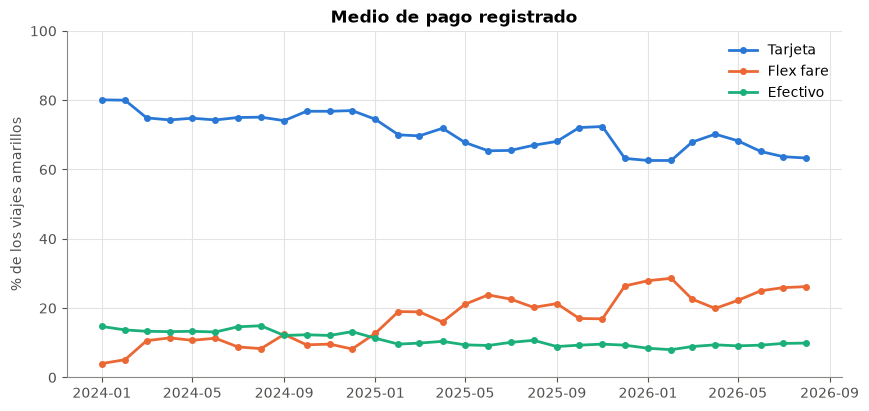

In [16]:
fig, ax = plt.subplots()
for column, label, color in [("pct_card", "Tarjeta", "#2a78d6"), ("pct_flex_fare", "Flex fare", "#eb6834"), ("pct_cash", "Efectivo", "#1baf7a")]:
    ax.plot(payment.month, payment[column], marker="o", markersize=4, color=color, label=label)
ax.set_ylim(0, 100)
ax.set_ylabel("% de los viajes amarillos")
ax.set_title("Medio de pago registrado")
ax.legend()
plt.show()

### Cargo de congestión CBD y monto promedio (amarillos)

In [17]:
cbd = taxi_db.show(con, "08_three_years/05_cbd_fee_rollout.sql")
cbd

SELECT
    make_date(source_year, source_month, 1) AS month,
    round(100.0 * count(*) FILTER (WHERE cbd_congestion_fee > 0) / count(*), 1) AS pct_trips_with_fee,
    round(coalesce(sum(cbd_congestion_fee), 0) / 1e6, 2) AS cbd_fee_musd,
    round(avg(total_amount), 2) AS avg_ticket
FROM trips_clean
WHERE taxi_type = 'yellow'
GROUP BY ALL
ORDER BY month;


,month,pct_trips_with_fee,cbd_fee_musd,avg_ticket
0,2024-01-01,0.0,0.00,27.34
1,2024-02-01,0.0,0.00,27.23
2,2024-03-01,0.0,0.00,27.85
3,2024-04-01,0.0,0.00,28.18
4,2024-05-01,0.0,0.00,28.99
5,2024-06-01,0.0,0.00,28.68
6,2024-07-01,0.0,0.00,28.97
7,2024-08-01,0.0,0.00,29.21
8,2024-09-01,0.0,0.00,29.48
9,2024-10-01,0.0,0.00,29.38


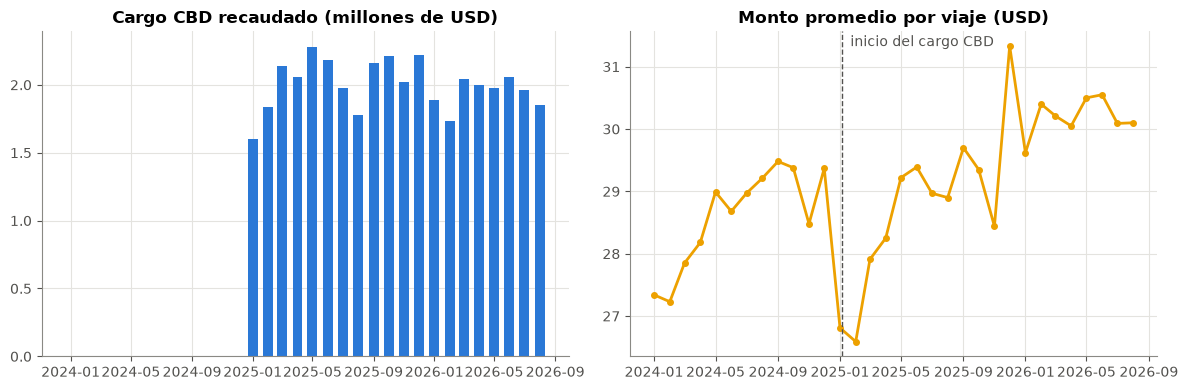

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(cbd.month, cbd.cbd_fee_musd, width=20, color="#2a78d6")
axes[0].set_title("Cargo CBD recaudado (millones de USD)")
axes[1].plot(cbd.month, cbd.avg_ticket, marker="o", markersize=4, color="#eda100")
axes[1].axvline(pd.Timestamp("2025-01-05"), color="#52514e", linestyle="--", linewidth=1)
axes[1].annotate("inicio del cargo CBD", (pd.Timestamp("2025-01-05"), cbd.avg_ticket.max()), xytext=(6, 0), textcoords="offset points", color="#52514e")
axes[1].set_title("Monto promedio por viaje (USD)")
plt.tight_layout()
plt.show()

### Participación de cada proveedor

In [19]:
vendors = taxi_db.show(con, "08_three_years/04_vendor_share.sql")
vendors

SELECT
    taxi_type,
    source_year AS year,
    VendorID AS vendor_id,
    count(*) AS trips,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY taxi_type, source_year), 2) AS pct_of_year
FROM trips_clean
GROUP BY taxi_type, source_year, VendorID
ORDER BY taxi_type DESC, year, vendor_id;


,taxi_type,year,vendor_id,trips,pct_of_year
0,yellow,2024,1,9418262,23.73
1,yellow,2024,2,30268261,76.26
2,yellow,2024,6,1578,0.00
3,yellow,2024,7,228,0.00
4,yellow,2025,1,9424645,21.09
5,yellow,2025,2,34714955,77.68
6,yellow,2025,6,22756,0.05
7,yellow,2025,7,527761,1.18
8,yellow,2026,1,5373610,18.79
9,yellow,2026,2,22801117,79.74


### Volumen crudo frente a limpio (amarillos, enero a agosto)

2025 descarta más del doble que los otros años: 1.2 millones de registros *flex fare* con tarifa negativa y un total de pocos dólares en esos meses.

In [20]:
volume = taxi_db.show(con, "08_three_years/06_volume_raw_vs_clean.sql")
volume

WITH common_months AS (
    SELECT CAST(regexp_extract(file, '-(\d{2})\.parquet$', 1) AS INTEGER) AS month
    FROM glob('data/raw/yellow/*/*.parquet')
    GROUP BY month
    HAVING count(*) = (SELECT count(DISTINCT split_part(file, '/', 4)) FROM glob('data/raw/yellow/*/*.parquet'))
),
raw AS (
    SELECT source_year, count(*) AS trips, count(*) FILTER (WHERE payment_type = 0 AND fare_amount < 0 AND total_amount > 0) AS flex_negative_fare
    FROM trips
    WHERE taxi_type = 'yellow' AND source_month IN (SELECT month FROM common_months)
    GROUP BY source_year
),
clean AS (
    SELECT source_year, count(*) AS trips
    FROM trips_clean
    WHERE taxi_type = 'yellow' AND source_month IN (SELECT month FROM common_months)
    GROUP BY source_year
)
SELECT
    source_year AS year,
    raw.trips AS raw_trips,
    clean.trips AS clean_trips,
    round(100.0 * (raw.trips - clean.trips) / raw.trips, 2) AS pct_discarded,
    raw.flex_negative_fare,
    round(100.0 * (raw.trips / lag(raw.trips)

,year,raw_trips,clean_trips,pct_discarded,flex_negative_fare,raw_growth_pct,clean_growth_pct
0,2024,26388179,25499652,3.37,73235,NaN,NaN
1,2025,31556438,28978563,8.17,1223597,19.6,13.6
2,2026,29703355,28593831,3.74,135,-5.9,-1.3
